In [1]:
!pip install spectral

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import glob

In [3]:
#base = r'C:/Users/PhD24-2/Downloads/M3d1d2/'

In [68]:
def find_m3_pairs(folder):
    """
    Automatically find matching RFL + LOC files
    """
    
    rfl_files = sorted(glob.glob(os.path.join(folder, "*_RFL.HDR")))
    
    pairs = []
    
    for rfl in rfl_files:
        loc = rfl.replace("_RFL.HDR", "_LOC.HDR")
        
        if os.path.exists(loc):
            pairs.append((rfl, loc))
        else:
            print(f"Missing LOC for: {rfl}")
    
    return pairs

def load_m3_dataset(rfl_hdr, loc_hdr):
    
    rfl = open_image(rfl_hdr)
    data = rfl.load()
    
    loc = open_image(loc_hdr)
    loc_data = loc.load()
    
    lon = np.array(loc_data[:, :, 0])
    lat = np.array(loc_data[:, :, 1])
    
    return data, lat, lon

def process_m3(data, lat, lon, band_index=40):
    
    band = np.array(data[:, :, band_index])
    
    lat = lat.flatten()
    lon = lon.flatten()
    band = band.flatten()
    
    # Remove invalid values
    mask = band > -900
    
    lat = lat[mask]
    lon = lon[mask]
    band = band[mask]
    
    # Fix longitude range
    lon = np.where(lon > 180, lon - 360, lon)
    
    return lat, lon, band

def cylindrical_projection_clean(lat, lon, values, res=0.1):
    
    lat_bins = np.arange(np.min(lat), np.max(lat), res)
    lon_bins = np.arange(np.min(lon), np.max(lon), res)
    
    grid_sum, _, _ = np.histogram2d(lat, lon, bins=[lat_bins, lon_bins], weights=values)
    grid_count, _, _ = np.histogram2d(lat, lon, bins=[lat_bins, lon_bins])
    
    grid = grid_sum / np.maximum(grid_count, 1)
    grid[grid_count == 0] = np.nan
    
    Lon, Lat = np.meshgrid(lon_bins[:-1], lat_bins[:-1])
    
    return Lon, Lat, grid

def plot_map(Lon, Lat, grid, title):
    
    plt.figure(figsize=(8,6))
    
    plt.imshow(
        grid,
        extent=[Lon.min(), Lon.max(), Lat.min(), Lat.max()],
        origin='lower',
        cmap='gray',
        aspect='auto'
    )
    
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar(label="Reflectance")
    
    plt.show()

In [69]:
folder = "C:/Users/PhD24-2/Downloads/M3d1d2/"

pairs = find_m3_pairs(folder)

print(f"Found {len(pairs)} datasets")

Missing LOC for: C:/Users/PhD24-2/Downloads/M3d1d2\M3D3_V01_RFL.HDR
Missing LOC for: C:/Users/PhD24-2/Downloads/M3d1d2\M3D4_V01_RFL.HDR
Missing LOC for: C:/Users/PhD24-2/Downloads/M3d1d2\M3D5_V01_RFL.HDR
Found 2 datasets


Processing: M3D1_V01_RFL.HDR


C:\Users\PhD24-2\anaconda3\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


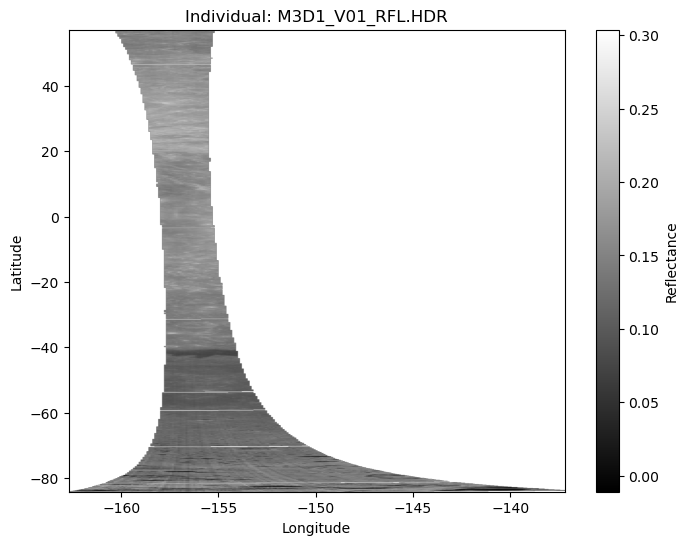

Processing: M3D2_V01_RFL.HDR


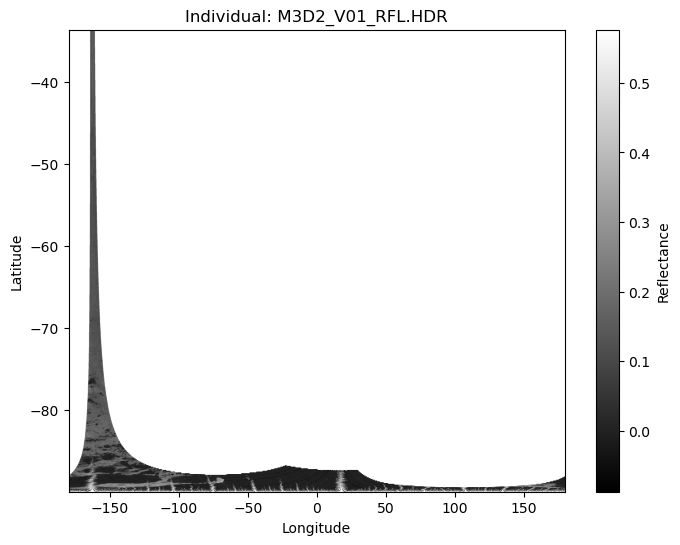

In [6]:
all_lat = []
all_lon = []
all_val = []

for rfl, loc in pairs:
    
    name = os.path.basename(rfl)
    print("Processing:", name)
    
    data, lat, lon = load_m3_dataset(rfl, loc)
    
    lat_f, lon_f, val_f = process_m3(data, lat, lon)
    
    # Save for mosaic
    all_lat.append(lat_f)
    all_lon.append(lon_f)
    all_val.append(val_f)
    
    # Individual plot
    Lon, Lat, grid = cylindrical_projection_clean(lat_f, lon_f, val_f)
    
    plot_map(Lon, Lat, grid, title=f"Individual: {name}")

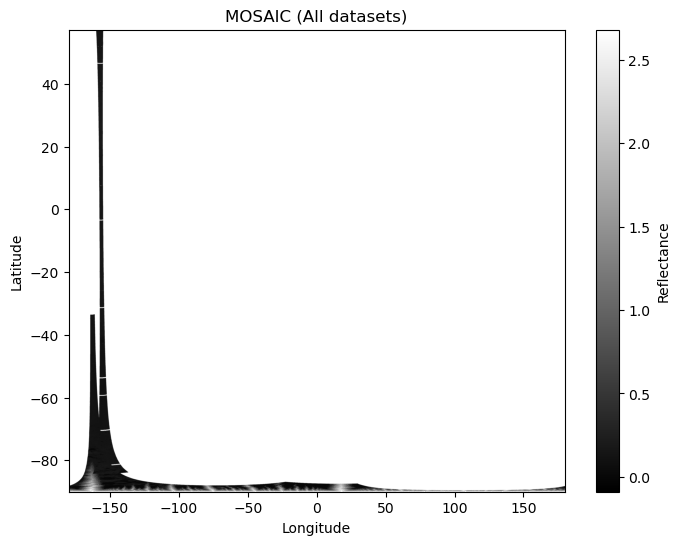

In [7]:
lat_all = np.concatenate(all_lat)
lon_all = np.concatenate(all_lon)
val_all = np.concatenate(all_val)

Lon, Lat, grid = cylindrical_projection_clean(lat_all, lon_all, val_all, res=0.05)

plot_map(Lon, Lat, grid, title="MOSAIC (All datasets)")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image
import glob
import os

In [9]:
def find_m3_pairs(folder):
    rfl_files = sorted(glob.glob(os.path.join(folder, "*_RFL.HDR")))
    
    pairs = []
    for rfl in rfl_files:
        loc = rfl.replace("_RFL.HDR", "_LOC.HDR")
        if os.path.exists(loc):
            pairs.append((rfl, loc))
    
    return pairs

def load_m3_dataset(rfl_hdr, loc_hdr):
    
    rfl = open_image(rfl_hdr)
    data = rfl.load()
    
    loc = open_image(loc_hdr)
    loc_data = loc.load()
    
    lon = np.array(loc_data[:, :, 0])
    lat = np.array(loc_data[:, :, 1])
    
    return data, lat, lon

def process_m3(data, lat, lon, band_index=40, lat_limit=-60):
    
    band = np.array(data[:, :, band_index])
    
    lat = lat.flatten()
    lon = lon.flatten()
    band = band.flatten()
    
    mask = band > -900
    
    lat = lat[mask]
    lon = lon[mask]
    band = band[mask]
    
    # Polar restriction
    polar_mask = lat < lat_limit
    
    lat = lat[polar_mask]
    lon = lon[polar_mask]
    band = band[polar_mask]
    
    # Longitude fix
    lon = np.where(lon > 180, lon - 360, lon)
    
    return lat, lon, band

def south_polar_projection(lat, lon):
    """
    Stable polar projection:
    Pole at center, radial distance from pole
    """
    
    r = 90 + lat
    theta = np.radians(lon)
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    return x, y

def polar_grid(x, y, values, res=0.2):
    
    x_bins = np.arange(np.min(x), np.max(x), res)
    y_bins = np.arange(np.min(y), np.max(y), res)
    
    grid_sum, _, _ = np.histogram2d(
        y, x,
        bins=[y_bins, x_bins],
        weights=values
    )
    
    grid_count, _, _ = np.histogram2d(
        y, x,
        bins=[y_bins, x_bins]
    )
    
    grid = grid_sum / np.maximum(grid_count, 1)
    grid[grid_count == 0] = np.nan
    
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
    
    return X, Y, grid

def plot_polar(X, Y, grid, title):
    
    plt.figure(figsize=(7,7))
    
    plt.imshow(
        grid,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin='lower',
        cmap='gray'
    )
    
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.colorbar(label="Reflectance")
    
    plt.axis('equal')
    plt.show()



Found 2 datasets
Processing: M3D1_V01_RFL.HDR


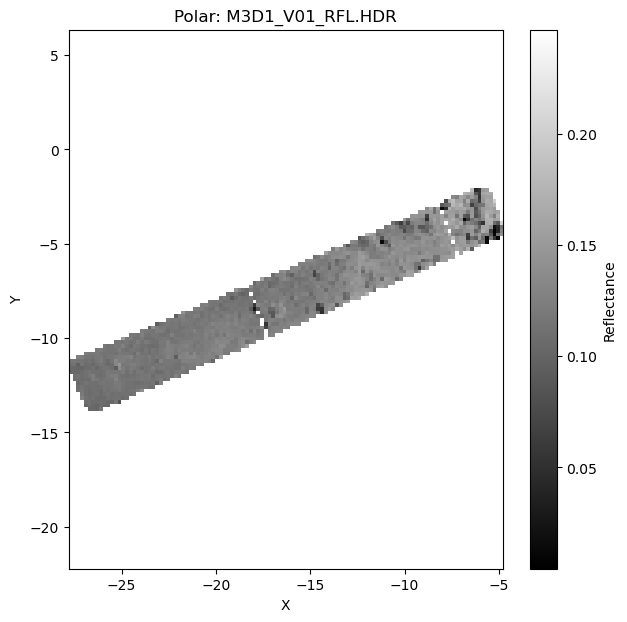

Processing: M3D2_V01_RFL.HDR


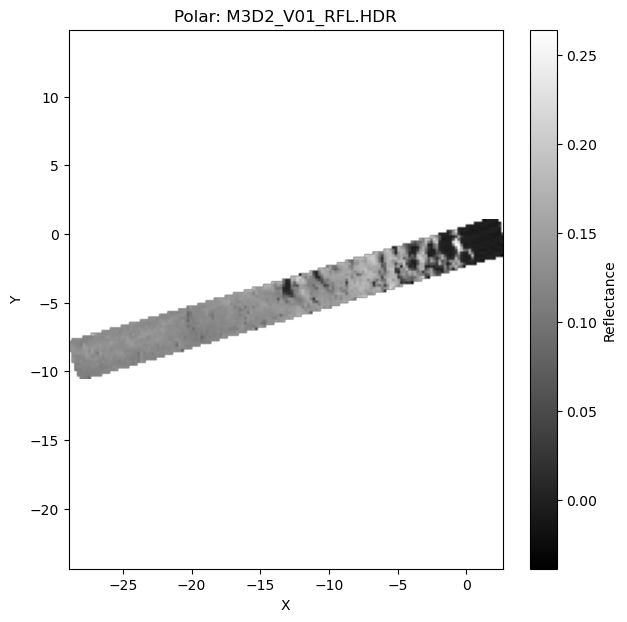

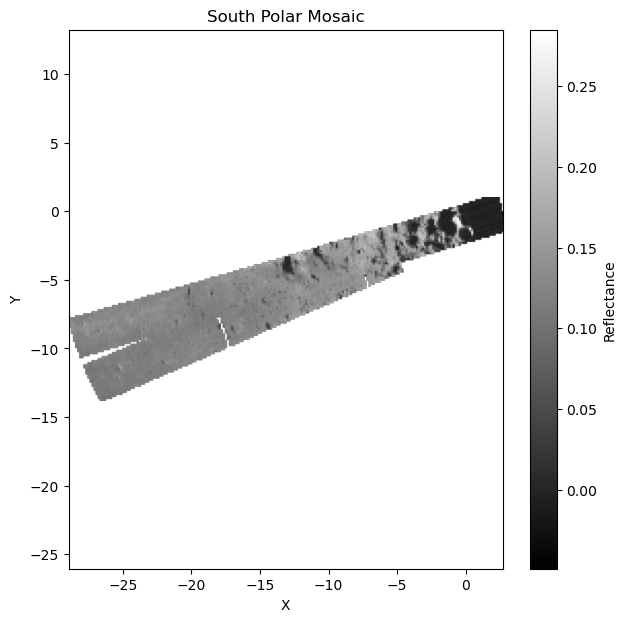

In [10]:
folder = "C:/Users/PhD24-2/Downloads/M3d1d2/"

pairs = find_m3_pairs(folder)

print(f"Found {len(pairs)} datasets")

all_x = []
all_y = []
all_val = []

for rfl, loc in pairs:
    
    name = os.path.basename(rfl)
    print("Processing:", name)
    
    data, lat, lon = load_m3_dataset(rfl, loc)
    
    lat, lon, band = process_m3(data, lat, lon)
    
    x, y = south_polar_projection(lat, lon)
    
    all_x.append(x)
    all_y.append(y)
    all_val.append(band)
    
    # Individual
    X, Y, grid = polar_grid(x, y, band)
    plot_polar(X, Y, grid, f"Polar: {name}")

x_all = np.concatenate(all_x)
y_all = np.concatenate(all_y)
val_all = np.concatenate(all_val)

X, Y, grid = polar_grid(x_all, y_all, val_all, res=0.15)

plot_polar(X, Y, grid, "South Polar Mosaic")

In [11]:
def find_m3_pairs(folder):
    rfl_files = sorted(glob.glob(os.path.join(folder, "*_RFL.HDR")))
    
    pairs = []
    for rfl in rfl_files:
        loc = rfl.replace("_RFL.HDR", "_LOC.HDR")
        if os.path.exists(loc):
            pairs.append((rfl, loc))
    
    return pairs

def load_m3_dataset(rfl_hdr, loc_hdr):
    
    rfl = open_image(rfl_hdr)
    data = rfl.load()
    
    loc = open_image(loc_hdr)
    loc_data = loc.load()
    
    lon = np.array(loc_data[:, :, 0])
    lat = np.array(loc_data[:, :, 1])
    
    return data, lat, lon

def process_m3(data, lat, lon, band_index=40, lat_limit=-60):
    
    band = np.array(data[:, :, band_index])
    
    lat = lat.flatten()
    lon = lon.flatten()
    band = band.flatten()
    
    mask = band > -900
    
    lat = lat[mask]
    lon = lon[mask]
    band = band[mask]
    
    # Polar restriction
    polar_mask = lat < lat_limit
    
    lat = lat[polar_mask]
    lon = lon[polar_mask]
    band = band[polar_mask]
    
    # Longitude fix
    lon = np.where(lon > 180, lon - 360, lon)
    
    return lat, lon, band

def polar_projection(lat, lon, pole='south'):
    """
    General polar projection (stable)
    
    pole = 'north' or 'south'
    """
    
    lon = np.where(lon > 180, lon - 360, lon)
    
    theta = np.radians(lon)
    
    if pole == 'south':
        r = 90 + lat
    elif pole == 'north':
        r = 90 - lat
    else:
        raise ValueError("pole must be 'north' or 'south'")
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    return x, y

def polar_grid(x, y, values, res=0.25):
    
    if len(x) == 0:
        return None, None, None
    
    x_bins = np.arange(np.min(x), np.max(x), res)
    y_bins = np.arange(np.min(y), np.max(y), res)
    
    if len(x_bins) < 2 or len(y_bins) < 2:
        return None, None, None
    
    grid_sum, _, _ = np.histogram2d(
        y, x,
        bins=[y_bins, x_bins],
        weights=values
    )
    
    grid_count, _, _ = np.histogram2d(
        y, x,
        bins=[y_bins, x_bins]
    )
    
    grid = grid_sum / np.maximum(grid_count, 1)
    grid[grid_count == 0] = np.nan
    
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
    
    return X, Y, grid

def plot_polar(X, Y, grid, title):
    
    plt.figure(figsize=(7,7))
    
    plt.imshow(
        grid,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin='lower',
        cmap='gray'
    )
    
    plt.title(title)
    plt.colorbar(label="Reflectance")
    
    plt.axis('equal')  # IMPORTANT (circular geometry)
    plt.xlabel("X")
    plt.ylabel("Y")
    
    plt.show()



Found 2 datasets
Processing: M3D1_V01_RFL.HDR


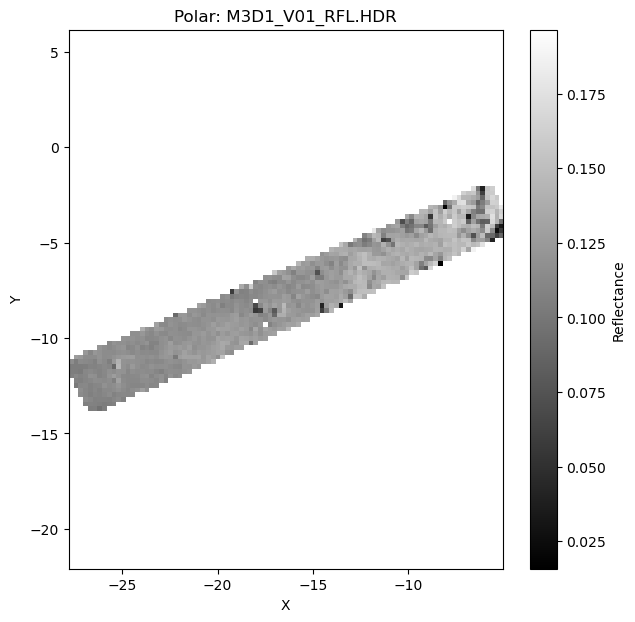

Processing: M3D2_V01_RFL.HDR


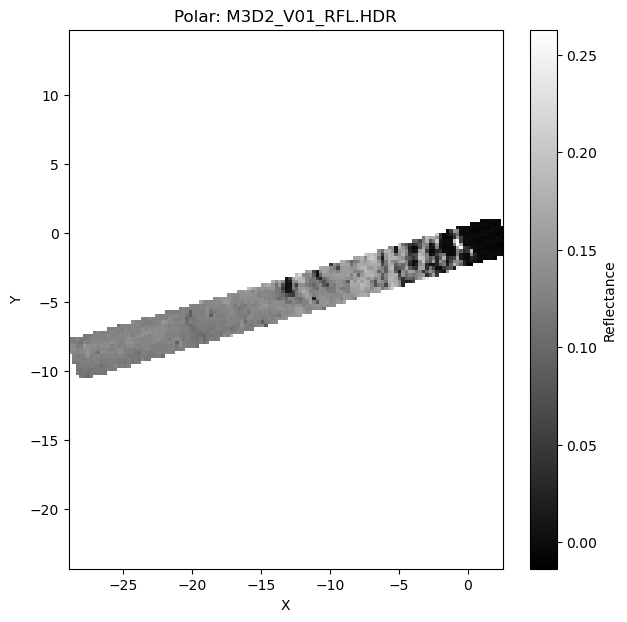

In [12]:
folder = "C:/Users/PhD24-2/Downloads/M3d1d2/"

pairs = find_m3_pairs(folder)

print(f"Found {len(pairs)} datasets")

all_x = []
all_y = []
all_val = []

for rfl, loc in pairs:
    
    name = os.path.basename(rfl)
    print("Processing:", name)
    
    data, lat, lon = load_m3_dataset(rfl, loc)
    
    lat, lon, band = process_m3(data, lat, lon)
    
    x, y = polar_projection(lat, lon, pole='south')  # or 'north'
    
    all_x.append(x)
    all_y.append(y)
    all_val.append(band)
    
    # Individual
    X, Y, grid = polar_grid(x, y, band)
    plot_polar(X, Y, grid, f"Polar: {name}")



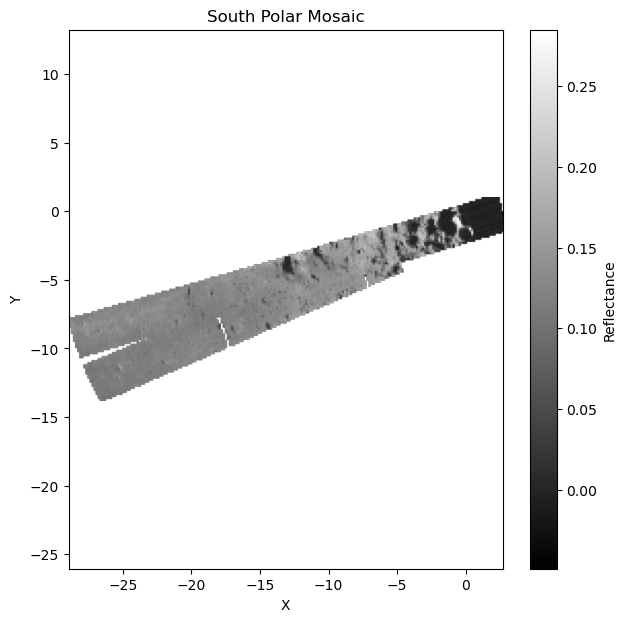

In [13]:
x_all = np.concatenate(all_x)
y_all = np.concatenate(all_y)
val_all = np.concatenate(all_val)

X, Y, grid = polar_grid(x_all, y_all, val_all, res=0.15)

plot_polar(X, Y, grid, "South Polar Mosaic")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image
import glob
import os

In [15]:
def find_m3_pairs(folder):

    rfl_files = sorted(glob.glob(os.path.join(folder, "*_RFL.HDR")))

    pairs = []

    for rfl in rfl_files:

        loc = rfl.replace("_RFL.HDR", "_LOC.HDR")

        if os.path.exists(loc):
            pairs.append((rfl, loc))

    return pairs

def load_m3_dataset(rfl_hdr, loc_hdr):

    # Reflectance
    rfl = open_image(rfl_hdr)
    data = rfl.load()

    # Location
    loc = open_image(loc_hdr)
    loc_data = loc.load()

    lon = np.array(loc_data[:, :, 0])
    lat = np.array(loc_data[:, :, 1])

    return data, lat, lon

def extract_band(data, lat, lon, band_index=40):

    band = np.array(data[:, :, band_index])

    lat = lat.flatten()
    lon = lon.flatten()
    band = band.flatten()

    # Remove invalid values
    mask = band > -900

    lat = lat[mask]
    lon = lon[mask]
    band = band[mask]

    # Longitude wrap
    lon = np.where(lon > 180, lon - 360, lon)

    return lat, lon, band




In [16]:
folder = "C:/Users/PhD24-2/Downloads/M3d1d2/"

pairs = find_m3_pairs(folder)

print("Found datasets:", len(pairs))

all_lat = []
all_lon = []
all_band = []

for rfl, loc in pairs:

    print("Loading:", os.path.basename(rfl))

    data, lat, lon = load_m3_dataset(rfl, loc)

    lat, lon, band = extract_band(data, lat, lon)

    all_lat.append(lat)
    all_lon.append(lon)
    all_band.append(band)

Found datasets: 2
Loading: M3D1_V01_RFL.HDR
Loading: M3D2_V01_RFL.HDR


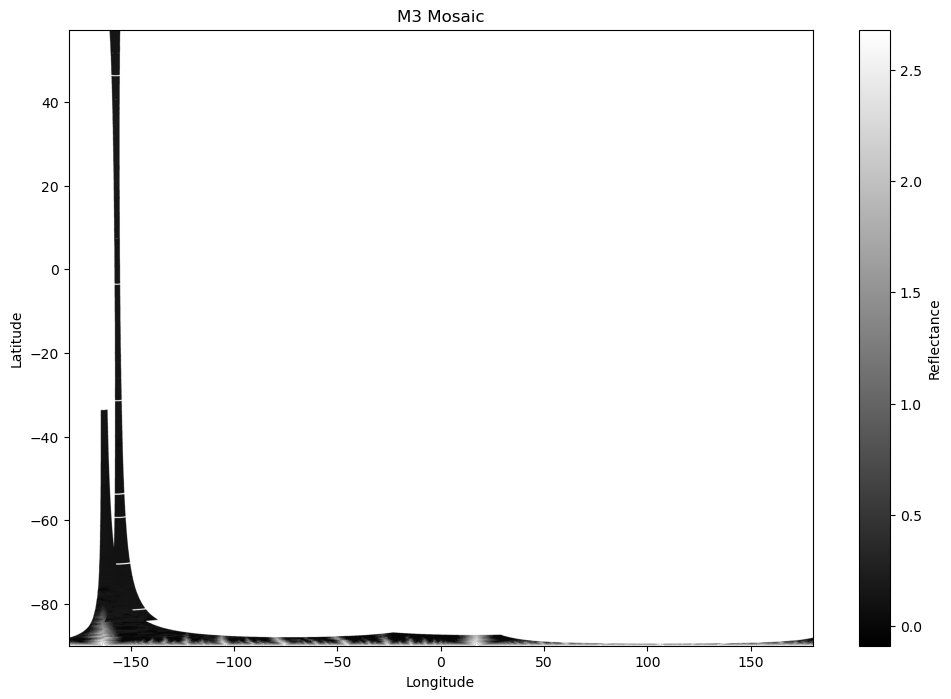

In [17]:
lat_all = np.concatenate(all_lat)
lon_all = np.concatenate(all_lon)
band_all = np.concatenate(all_band)

# Grid resolution
res = 0.05

lat_bins = np.arange(np.min(lat_all), np.max(lat_all), res)
lon_bins = np.arange(np.min(lon_all), np.max(lon_all), res)

# Average reflectance inside each bin
grid_sum, _, _ = np.histogram2d(
    lat_all,
    lon_all,
    bins=[lat_bins, lon_bins],
    weights=band_all
)

grid_count, _, _ = np.histogram2d(
    lat_all,
    lon_all,
    bins=[lat_bins, lon_bins]
)

grid = grid_sum / np.maximum(grid_count, 1)

grid[grid_count == 0] = np.nan

plt.figure(figsize=(12,8))

plt.imshow(
    grid,
    extent=[
        lon_bins.min(),
        lon_bins.max(),
        lat_bins.min(),
        lat_bins.max()
    ],
    origin='lower',
    cmap='gray',
    aspect='auto'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("M3 Mosaic")

plt.colorbar(label="Reflectance")

plt.show()

Processing: M3D1_V01_RFL.HDR


C:\Users\PhD24-2\AppData\Local\Temp\ipykernel_17788\824939564.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  valid_fraction[b] = np.mean(band > invalid_threshold)


Processing: M3D2_V01_RFL.HDR
(2, 85)


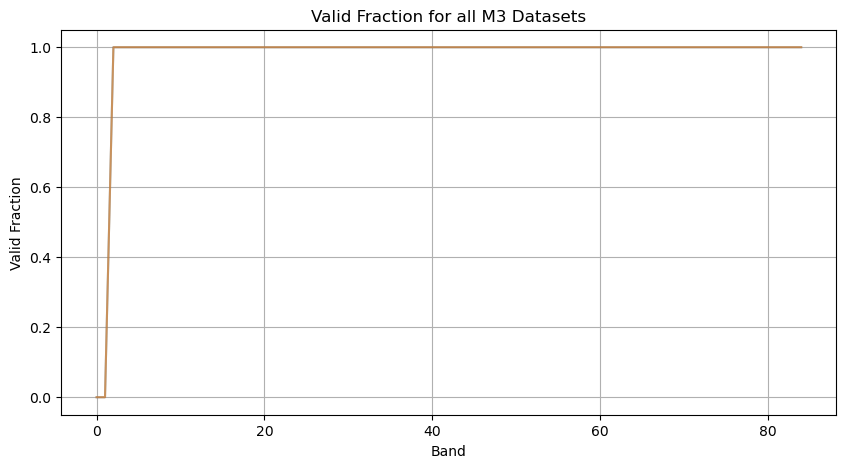

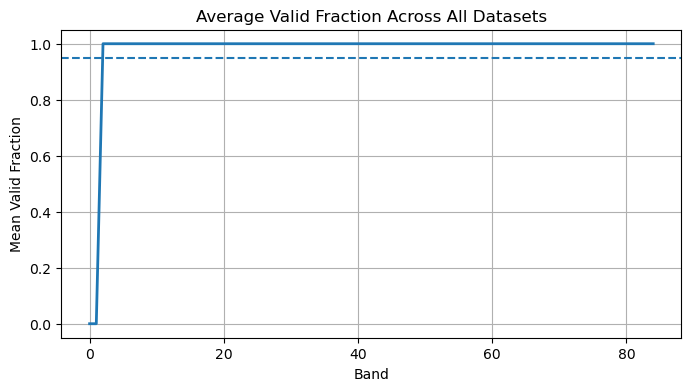

Number of good bands: 83
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84]


In [28]:
import numpy as np

def band_valid_fraction(data, invalid_threshold=-900):
    """
    data shape = (lines, samples, bands)

    Returns:
        valid_fraction : array of length n_bands
    """

    n_bands = data.shape[2]

    valid_fraction = np.zeros(n_bands)

    for b in range(n_bands):

        band = data[:, :, b]

        valid_fraction[b] = np.mean(band > invalid_threshold)

    return valid_fraction

all_valid = []

for rfl, loc in pairs:

    print("Processing:", os.path.basename(rfl))

    data, lat, lon = load_m3_dataset(rfl, loc)

    vf = band_valid_fraction(data)

    all_valid.append(vf)

all_valid = np.array(all_valid)

print(all_valid.shape)

plt.figure(figsize=(10,5))

for i in range(len(all_valid)):
    plt.plot(all_valid[i], alpha=0.6)

plt.xlabel("Band")
plt.ylabel("Valid Fraction")

plt.title("Valid Fraction for all M3 Datasets")

plt.grid(True)

plt.show()

mean_valid = np.mean(all_valid, axis=0)

#for b, frac in enumerate(mean_valid):
    #print(f"Band {b:2d}: {frac:.4f}")

plt.figure(figsize=(8,4))

plt.plot(mean_valid, linewidth=2)

plt.axhline(0.95, linestyle='--')

plt.xlabel("Band")
plt.ylabel("Mean Valid Fraction")

plt.title("Average Valid Fraction Across All Datasets")

plt.grid(True)

plt.show()

good_bands = np.where(mean_valid > 0.95)[0]

print("Number of good bands:", len(good_bands))
print(good_bands)

-90.0 58.0
-180.0 180.0
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84]


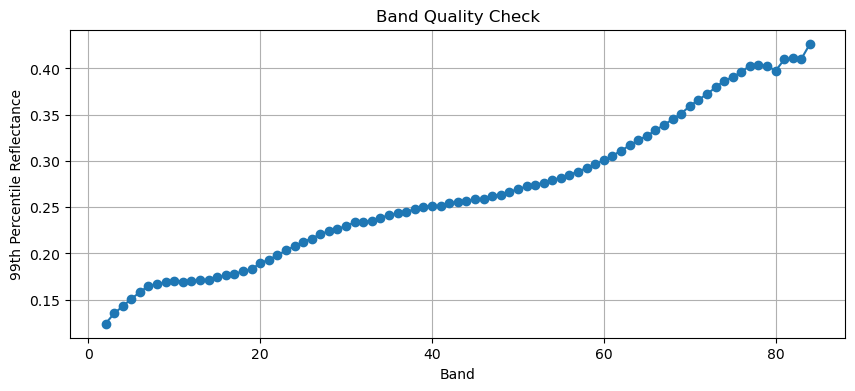

In [50]:
lat_min = np.floor(lat_all.min())
lat_max = np.ceil(lat_all.max())

lon_min = np.floor(lon_all.min())
lon_max = np.ceil(lon_all.max())

print(lat_min, lat_max)
print(lon_min, lon_max)

res = 0.05
lat_bins = np.arange(lat_min, lat_max + res, res)
lon_bins = np.arange(lon_min, lon_max + res, res)

n_lat = len(lat_bins) - 1
n_lon = len(lon_bins) - 1

n_bands = len(good_bands)

valid = (
    (cube_flat > -900) &
    (cube_flat < 1.0)
)
valid_pixels = np.all(
    (cube_flat > -900) &
    (cube_flat < 0.8),
    axis=1
)

for b in range(data.shape[2]):

    band = np.array(data[:, :, b])

    valid = band > -900

    n_valid = np.sum(valid)

    if n_valid > 0:
        p99 = np.percentile(band[valid], 99)

    #     print(
    #         f"Band {b:2d} | "
    #         f"Valid = {n_valid:8d} | "
    #         f"P99 = {p99:.3f}"
    #     )
    # else:
    #     print(
    #         f"Band {b:2d} | "
    #         f"Valid = 0"
    #     )

n_pixels = data.shape[0] * data.shape[1]

valid_fraction = []

for b in range(data.shape[2]):

    band = np.array(data[:, :, b])

    frac = np.sum(band > -900) / n_pixels

    valid_fraction.append(frac)

    #print(f"Band {b:2d}: {frac:.3f}")

good_bands = np.where(
    np.array(valid_fraction) > 0.95
)[0]

print(good_bands)

stats = []

n_pixels = data.shape[0] * data.shape[1]

for b in range(data.shape[2]):

    band = np.array(data[:, :, b])

    valid = band > -900

    if np.sum(valid) == 0:
        continue

    stats.append([
        b,
        np.mean(valid),
        np.percentile(band[valid], 99),
        np.max(band[valid])
    ])

stats = np.array(stats)

plt.figure(figsize=(10,4))

plt.plot(stats[:,0], stats[:,2], '-o')

plt.xlabel("Band")
plt.ylabel("99th Percentile Reflectance")
plt.title("Band Quality Check")

plt.grid(True)

plt.show()

In [62]:
band_start = 2

n_bands = data.shape[2] - band_start

cube_flat = cube.reshape(-1, data.shape[2])

cube_flat = cube_flat[:, band_start:]
print(cube_flat.shape)
print(n_bands)

(3668064, 83)
83


In [89]:
lat_min = np.floor(lat_all.min())
lat_max = np.ceil(lat_all.max())

lon_min = np.floor(lon_all.min())
lon_max = np.ceil(lon_all.max())

# print(lat_min, lat_max)
# print(lon_min, lon_max)

res = 0.05
lat_bins = np.arange(lat_min, lat_max + res, res)
lon_bins = np.arange(lon_min, lon_max + res, res)

n_lat = len(lat_bins) - 1
n_lon = len(lon_bins) - 1

mosaic_sum = np.zeros(
    (n_lat, n_lon, n_bands),
    dtype=np.float32
)
        
mosaic_count = np.zeros(
    (n_lat, n_lon),
    dtype=np.uint16
)

for rfl, loc in pairs:
    print("Processing:", os.path.basename(rfl))

    data, lat, lon = load_m3_dataset(rfl, loc)

cube = np.array(data)
cube = cube[:,:,2:]

cube_flat = cube.reshape(-1, cube.shape[2])

lat_flat = lat.flatten()
lon_flat = lon.flatten()



lon_flat = np.where(
    lon_flat > 180,
    lon_flat - 360,
    lon_flat
)

row = np.digitize(lat_flat, lat_bins) - 1

col = np.digitize(lon_flat, lon_bins) - 1

inside = (
    (row >= 0) &
    (row < n_lat) &
    (col >= 0) &
    (col < n_lon)
)

row = row[inside]
col = col[inside]

cube_flat = cube_flat[inside]

for b in range(n_bands):

    np.add.at(
        mosaic_sum[:, :, b],
        (row, col),
        cube_flat[:, b]
    )
    
    np.add.at(
    mosaic_count,
    (row, col),
    1
)

# #####
# np.add.at(
#     mosaic_count,
#     (row, col),
#     1
# )
# ####

mosaic_cube = mosaic_sum.copy()

    
def load_m3_dataset_w(rfl_hdr, loc_hdr):

    rfl = open_image(rfl_hdr)
    cube = rfl.load()

    wavelengths = np.array(
        rfl.metadata['wavelength'],
        dtype=float
    )

    loc = open_image(loc_hdr)
    loc_cube = loc.load()

    lon = np.array(loc_cube[:, :, 0])
    lat = np.array(loc_cube[:, :, 1])

    return cube, lat, lon, wavelengths

for rfl, loc in pairs:
    
    data, lat, lon, wavelengths = load_m3_dataset_w(rfl,loc)
    
    wavelengths = wavelengths[2:]
    print(data.shape)
    print("Loading:", os.path.basename(rfl),data.shape)

print(len(wavelengths))

print("Check:" ,mosaic_cube.shape)

print("Original bands:", data.shape[2])
print("Using bands:", data.shape[2] - 2)
print("Wavelength range:")
print(wavelengths[0], "nm")
print(wavelengths[-1], "nm")

Processing: M3D1_V01_RFL.HDR
Processing: M3D2_V01_RFL.HDR
(28770, 304, 85)
Loading: M3D1_V01_RFL.HDR (28770, 304, 85)
(12066, 304, 85)
Loading: M3D2_V01_RFL.HDR (12066, 304, 85)
83
Check: (2960, 7200, 83)
Original bands: 85
Using bands: 83
Wavelength range:
540.84 nm
2976.2 nm


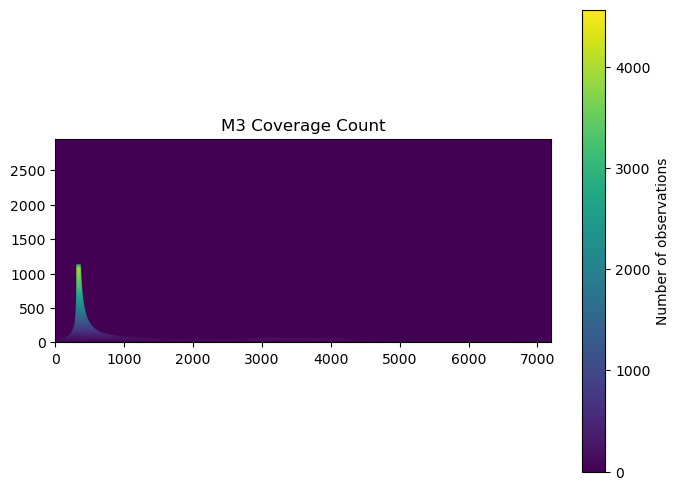

In [91]:
mosaic_cube = np.full(
    (n_lat, n_lon, n_bands),
    np.nan,
    dtype=np.float32
)

valid = mosaic_count > 0

for b in range(n_bands):

    mosaic_cube[:,:,b][valid] = (
        mosaic_sum[:,:,b][valid]
        / mosaic_count[valid]
    )

plt.figure(figsize=(8,6))

plt.imshow(
    mosaic_count,
    origin='lower'
)

plt.colorbar(label="Number of observations")
plt.title("M3 Coverage Count")

plt.show()

In [92]:
np.save("M3_hyperspectral_mosaic.npy", mosaic_cube)

# np.save("good_bands.npy", good_bands)

# np.save("lat_bins.npy", lat_bins)

# np.save("lon_bins.npy", lon_bins)

In [93]:
import numpy as np

mosaic_cube = np.load("M3_hyperspectral_mosaic.npy")

print(mosaic_cube.shape)
print(mosaic_cube.dtype)
print(mosaic_cube.shape)

print(np.nanmin(mosaic_cube))
print(np.nanmax(mosaic_cube))

(2960, 7200, 83)
float32
(2960, 7200, 83)
-0.009870478
0.05289171


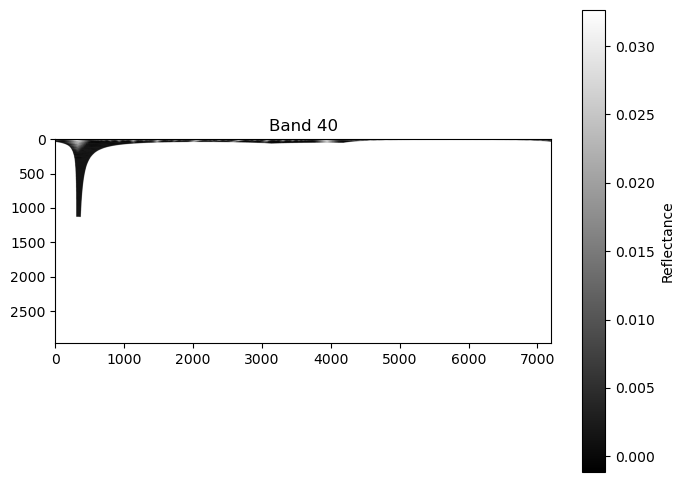

In [94]:
band = mosaic_cube[:, :, 40]

plt.figure(figsize=(8,6))
plt.imshow(band, cmap='gray')
plt.colorbar(label='Reflectance')
plt.title("Band 40")
plt.show()

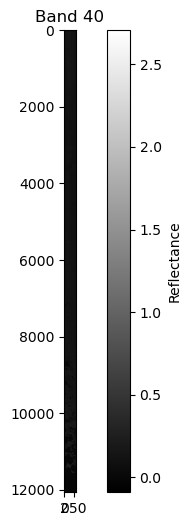

In [96]:
mid_band_idx = 40

plt.figure(figsize=(8,6))

plt.imshow(
    data[:, :, mid_band_idx],
    cmap='gray'
)

plt.title(f"Band {mid_band_idx}")
plt.colorbar(label="Reflectance")

plt.show()

Min: -0.09887902
Max: 3.0057347
Mean: 0.11822311
[-0.02030396 -0.00110613  0.12447993  0.19364411  0.25569536]


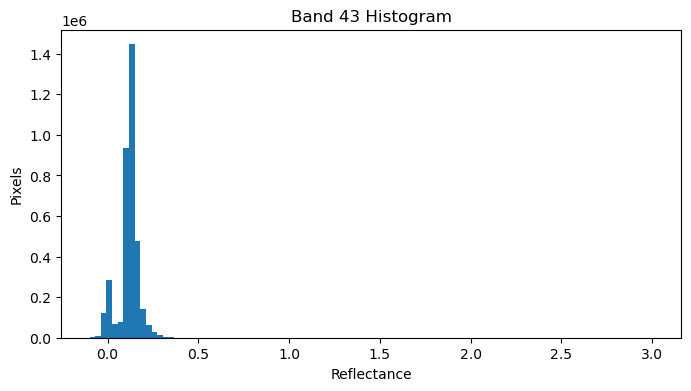

In [97]:
band = np.array(data[:, :, 43])

valid = band > -900

print("Min:", np.min(band[valid]))
print("Max:", np.max(band[valid]))
print("Mean:", np.mean(band[valid]))

print(
    np.percentile(
        band[valid],
        [1, 5, 50, 95, 99]
    )
)

plt.figure(figsize=(8,4))

plt.hist(
    band[valid].flatten(),
    bins=100
)

plt.xlabel("Reflectance")
plt.ylabel("Pixels")

plt.title("Band 43 Histogram")

plt.show()

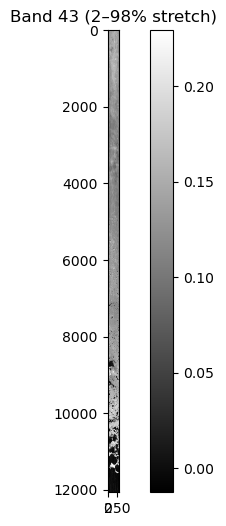

15
12
1


In [43]:
band = np.array(data[:, :, 43])

valid = band > -900

vmin = np.percentile(band[valid], 2)
vmax = np.percentile(band[valid], 98)

plt.figure(figsize=(8,6))

plt.imshow(
    band,
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar()
plt.title("Band 43 (2–98% stretch)")
plt.show()

print(np.sum(band > 1))
print(np.sum(band > 2))
print(np.sum(band > 3))



## CHanged

In [18]:
mean_val = np.mean(band_1_flattened_cleaned)
std_val = np.std(band_1_flattened_cleaned)

upper_tail = mean_val + 3 * std_val

print(f"Mean: {mean_val:.4f}")
print(f"Std Dev: {std_val:.4f}")
print(f"Upper 3σ threshold: {upper_tail:.4f}")

lower_tail = mean_val - 3 * std_val
print(f"Lower 3σ threshold: {lower_tail:.4f}")

extreme_pixels = band_1_flattened_cleaned[band_1_flattened_cleaned > upper_tail]

print("Number of extreme pixels:", extreme_pixels.size)
print("Fraction (%):", 100 * extreme_pixels.size / band_1_flattened_cleaned.size)

p99 = np.percentile(band_1_flattened_cleaned, 99)

print("99th percentile:", p99)

NameError: name 'band_1_flattened_cleaned' is not defined

In [ ]:
# Compute meaningful threshold (top 1%)
threshold = np.percentile(band_1_flattened_cleaned, 99)

# Create outlier filter
outlier_filter_band1 = band_1_flattened_cleaned >= threshold

# Extract outliers
band_1_outliers = band_1_flattened_cleaned[outlier_filter_band1]

# Print info
print("Threshold (99th percentile):", threshold)
print("Outliers count:", band_1_outliers.size)
print("Fraction (%):", 100 * band_1_outliers.size / band_1_flattened_cleaned.size)

In [ ]:
# Total counts
num_outliers = band_1_outliers.size
num_total = band_1_flattened_cleaned.size

print('Total number of outliers:', num_outliers, 'pixels')
print('Total number of usable pixels:', num_total, 'pixels')

# Percentage
percentage = (num_outliers / num_total) * 100
print('Percentage of outliers:', percentage, '%')

In [ ]:
# -------- Analysis of the outliers population --------

quickstats(band_1_outliers)

fig = plt.figure(figsize=(7, 4))

sns.histplot(band_1_outliers, bins=100, stat="density", kde=True)

plt.title(f"Outlier Reflectance Distribution (Band {band_index})")
plt.xlabel("Reflectance")
plt.ylabel("Density")

plt.show()

In [ ]:
subset = pixels_cube_d1[5000:8000, :, :]   # crop rows to reduce size

subset = np.array(subset)

# Replace invalid values
subset[subset == -999] = np.nan
print("Eigenvalues:", pc.eigenvalues)


In [ ]:
subset = np.array(pixels_cube_d1[5000:8000, :, :])

# Create mask of valid pixels (across all bands)
valid_mask = np.all(subset != -999, axis=2)

# Keep only valid pixels
valid_pixels = subset[valid_mask]



In [ ]:
from spectral import envi
import numpy as np

# Open header (you already have this, but safe to reuse)
hdr_rfl_d1 = r"C:\Users\PhD24-2\Downloads\M3d1d2\M3D1_V01_RFL.HDR"
img_rfl_d1 = r"C:\Users\PhD24-2\Downloads\M3d1d2\M3D1_V01_RFL.IMG"

rfl_d1_obj = envi.open(hdr_rfl_d1, img_rfl_d1)

# Extract wavelengths from metadata
wavelengths = rfl_d1_obj.metadata.get('wavelength')

# Convert to float list
wavelengths = np.array(wavelengths, dtype=float)

print("Number of bands:", len(wavelengths))
print( wavelengths)

In [ ]:
## Accessing data of one pixel in the cube and inserting data into Numpy array:

row, col = 5000, 150   # valid indices for your data

test_pixel = np.array(pixels_cube_d1[row, col, :])  # Extract pixel spectrum

print("Shape of the numpy array prior to transformation:", test_pixel.shape)
print()

## Flattening extracted array (even though already 1D)
test_pixel = test_pixel.flatten()

print("Shape of the numpy array after transformation:", test_pixel.shape)
print()
print(test_pixel)

In [ ]:

# Remove invalid values
valid_pixel = test_pixel[test_pixel != -999]
print("Number of valid bands:", valid_pixel.size)
print('Min:', np.min(valid_pixel))
print('Max:', np.max(valid_pixel))
print('Mean:', np.mean(valid_pixel))
print('Median:', np.median(valid_pixel))
print('Stdev:', np.std(valid_pixel))
print('Skew:', stats.skew(valid_pixel))
print('Kurtosis:', stats.kurtosis(valid_pixel))

In [ ]:
import matplotlib.pyplot as plt

mask = test_pixel != -999

plt.plot(wavelengths[mask], test_pixel[mask])
plt.xlabel("Wavelength (µm)")
plt.ylabel("Reflectance")
plt.title("Pixel Spectrum")
plt.show()

In [ ]:
row, col = 5000, 150

pixel_longitude = pixels_locations_d1[row, col, 0]
pixel_latitude = pixels_locations_d1[row, col, 1]
pixel_elevation = pixels_locations_d1[row, col, 2]

# Convert longitude
if pixel_longitude > 180:
    pixel_longitude -= 360

print('pixel longitude:', pixel_longitude,
      ', pixel latitude:', pixel_latitude,
      ', pixel elevation:', pixel_elevation)

print("Raw longitude:", pixels_locations_d1[row, col, 0])

In [ ]:
valid_pixel = test_pixel[test_pixel != -999]
test_pixel = valid_pixel
print("Number of valid bands:", test_pixel.size)
#print(test_pixel)

In [ ]:
# Continuum removal
cr_pixel_spectrum = spectro.convex_hull_removal(test_pixel, wavelengths[:test_pixel.size])

# Convert outputs to numpy arrays
cr_spectrum = np.array(cr_pixel_spectrum[0])
hull_wavelengths = np.array(cr_pixel_spectrum[1])
hull_values = np.array(cr_pixel_spectrum[2])

# Print shape
print("Shape of continuum-removed spectrum:", cr_spectrum.shape)
print()
print("Continuum removed spectrum:", cr_spectrum)

In [ ]:
clean_wavelengths = clean_wavelengths / 1000 #(nm converted to mu_m)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1)
ax2 = ax.twinx()

# Labels
ax.set_xlabel("Wavelength (µm)", fontsize=11, color='black')
ax.set_ylabel("Reflectance", fontsize=11, color='red')
ax2.set_ylabel("Continuum Removed Reflectance", fontsize=11, color='blue')

# Convert to numpy arrays (safe)
cr_spectrum = np.array(cr_pixel_spectrum[0])

# Plot
ax.plot(clean_wavelengths, test_pixel, c='r', label='Raw Spectrum')
ax2.plot(clean_wavelengths, cr_spectrum, c='b', label='Continuum Removed')

# Optional legends
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title("Raw vs Continuum Removed Spectrum")
plt.show()

In [ ]:
cr_spectrum = np.array(cr_pixel_spectrum[0])

print('Min:', np.min(cr_spectrum))
print('Max:', np.max(cr_spectrum))
print('Mean:', np.mean(cr_spectrum))
print('Median:', np.median(cr_spectrum))
print('Stdev:', np.std(cr_spectrum))
print('Skew:', stats.skew(cr_spectrum))
print('Kurtosis:', stats.kurtosis(cr_spectrum))



In [ ]:
absorption_depth = 1 - np.min(cr_spectrum)
print("Max absorption depth:", absorption_depth)
min_index = np.argmin(cr_spectrum)
print("Strongest absorption at wavelength:", clean_wavelengths[min_index])

## Imaging


In [ ]:
#!pip install hyde
!pip install tqdm

In [ ]:
import spectral
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

import hyde   # make sure hyde is installed

In [ ]:

def soft_threshold(x, tau):
    return torch.sign(x) * torch.maximum(torch.abs(x) - tau, torch.tensor(0.0, device=x.device))

def diff(x):
    return x[1:, :] - x[:-1, :]

def diff_dim0_replace_last_row(x):
    last_row = x[-1:, :]
    return torch.cat([x, last_row], dim=0)

In [ ]:
class HyRes(torch.nn.Module):
    def __init__(self):
        super(HyRes, self).__init__()

    def forward(self, x):
        # Simple smoothing (approximate Gaussian noise removal)
        kernel = torch.ones((3, 3), device=x.device) / 9.0
        
        x_out = torch.zeros_like(x)
        
        for b in range(x.shape[2]):  # per band
            band = x[:, :, b]
            band = band.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
            
            band_filtered = torch.nn.functional.conv2d(
                band,
                kernel.unsqueeze(0).unsqueeze(0),
                padding=1
            )
            
            x_out[:, :, b] = band_filtered.squeeze()
        
        return x_out

In [ ]:
class HyMiNoR(torch.nn.Module):
    def __init__(self):
        super(HyMiNoR, self).__init__()
        self.hyres = HyRes()

    def forward(self, x, lam=10.0, iterations=50):
        base_dtype = x.dtype
        
        mu1, mu2, its = 0.5, 0.5, iterations
        
        # Step 1: HyRes
        H = self.hyres(x)

        m, n, d = H.shape
        mn = m * n

        Y = H.reshape((mn, d)).T

        l1 = torch.zeros((d, mn), device=x.device, dtype=x.dtype)
        l2 = torch.zeros((d, mn), device=x.device, dtype=x.dtype)
        v1 = torch.zeros((d, mn), device=x.device, dtype=x.dtype)
        v2 = torch.zeros((d, mn), device=x.device, dtype=x.dtype)
        xx = torch.zeros((d, mn), device=x.device, dtype=x.dtype)

        eye_d = torch.eye(d, device=x.device, dtype=x.dtype)

        D = diff(eye_d)
        D = diff_dim0_replace_last_row(D)

        u, s, v = torch.linalg.svd(D.to(torch.float64), full_matrices=False)
        v = v.T

        magic = (v @ torch.diag(1.0 / (mu1 + mu2 * s)) @ u.T).to(base_dtype)

        for i in tqdm(range(its), desc="HyMiNoR Progress"):

            hold1 = -mu1 * (v1 - Y - l1)
            
            # D^T (v2 - l2)
            hold2 = mu2 * (D.T @ (v2 - l2))
            
            xx = magic @ (hold1 + hold2)
            
            v1 = soft_threshold(Y - xx + l1, 1.0 / mu1)
            
            dv_xx = D @ xx   # proper gradient
            
            v2 = soft_threshold(dv_xx + l2, lam / mu2)
            
            l1 = l1 + (Y - xx - v1)
            l2 = l2 + (dv_xx - v2)

            # # optional metric
            # err = torch.norm(Y - xx).item()
            # tqdm.write(f"Iter {i}: error={err:.4f}")

        X = xx.T.reshape(m, n, d)

        return X

In [ ]:
hdr_file = r"C:\Users\PhD24-2\Downloads\M3d1d2\M3D1_V01_RFL.HDR"   # <-- change this

img = spectral.open_image(hdr_file)
cube = img.load()   # loads .rfl automatically

cube = np.array(cube, dtype=np.float32)

print("Cube shape:", cube.shape)   # (H, W, Bands)

cube_min = cube.min()
cube_max = cube.max()

cube_norm = (cube - cube_min) / (cube_max - cube_min)

In [ ]:
input_tens = torch.tensor(cube_norm, dtype=torch.float32)

# Convert to (Bands, H, W)
input_tens = input_tens.permute(2, 0, 1)

print("Tensor shape:", input_tens.shape)

In [ ]:
patch_size = 100

h, w, d = img.shape

output_full = np.zeros((h, w, d), dtype=np.float32)

model = HyMiNoR()

for i in range(0, h, patch_size):
    for j in range(0, w, patch_size):

        print(f"Patch {i}:{i+patch_size}, {j}:{j+patch_size}")

        # ✅ READ ONLY PATCH (from disk!)
        patch = img[i:i+patch_size, j:j+patch_size, :]
        patch = np.array(patch, dtype=np.float32)

        # Normalize per patch (important)
        patch = (patch - patch.min()) / (patch.max() - patch.min() + 1e-8)

        patch_t = torch.tensor(patch, dtype=torch.float32)

        out_patch = model(patch_t)

        output_full[i:i+patch.shape[0], j:j+patch.shape[1], :] = (
            out_patch.detach().numpy()
        )

In [ ]:
img = spectral.open_image(r"C:\Users\PhD24-2\Downloads\M3d1d2\M3D1_V01_RFL.HDR")
cube = img.load()
cube = np.array(cube, dtype=np.float32)

# Normalize
cube = (cube - cube.min()) / (cube.max() - cube.min())

input_tens = torch.tensor(cube, dtype=torch.float32)

model = HyMiNoR()
output = model(input_tens)


In [ ]:
rgb = output[:, :, [30, 20, 10]].detach().numpy()

# ✅ Normalize for display
rgb_min = rgb.min()
rgb_max = rgb.max()

rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)

plt.imshow(rgb)
plt.title("HyMiNoR Output (Normalized)")
plt.axis("off")
plt.show()

## Change

In [ ]:
import numpy as np
import torch
import pywt
import os

In [ ]:


##############################################
# ----------- ENVI DATA LOADER --------------
##############################################

def read_envi_hdr(hdr_path):
    metadata = {}
    with open(hdr_path, 'r') as f:
        for line in f:
            if '=' in line:
                key, val = line.strip().split('=', 1)
                metadata[key.strip().lower()] = val.strip()
    return metadata


def load_envi_cube(hdr_path, img_path):
    meta = read_envi_hdr(hdr_path)

    samples = int(meta['samples'])
    lines = int(meta['lines'])
    bands = int(meta['bands'])

    dtype_map = {
        '1': np.uint8,
        '2': np.int16,
        '4': np.float32,
        '5': np.float64
    }

    dtype = dtype_map[meta['data type']]
    interleave = meta.get('interleave', 'bsq').lower()

    data = np.fromfile(img_path, dtype=dtype)

    if interleave == 'bsq':
        cube = data.reshape((bands, lines, samples))
        cube = np.transpose(cube, (1, 2, 0))

    elif interleave == 'bil':
        cube = data.reshape((lines, bands, samples))
        cube = np.transpose(cube, (0, 2, 1))

    elif interleave == 'bip':
        cube = data.reshape((lines, samples, bands))

    else:
        raise ValueError("Unsupported interleave format")

    return cube


##############################################
# ----------- BASIC UTILITIES ---------------
##############################################

def soft_threshold(x, t):
    return torch.sign(x) * torch.clamp(torch.abs(x) - t, min=0.0)


def diff(x):
    return x[1:] - x[:-1]


def diff_dim0_replace_last_row(x):
    d = diff(x)
    last_row = d[-1:].clone()
    return torch.cat([d, last_row], dim=0)


##############################################
# ----------- PCA ---------------------------
##############################################

def custom_pca_image(x):
    # x: H x W x C
    h, w, c = x.shape
    reshaped = x.reshape(-1, c)

    mean = torch.mean(reshaped, dim=0)
    centered = reshaped - mean

    cov = centered.T @ centered / (reshaped.shape[0] - 1)

    eigvals, eigvecs = torch.linalg.eigh(cov)

    # sort descending
    idx = torch.argsort(eigvals, descending=True)
    eigvecs = eigvecs[:, idx]

    pc = torch.matmul(centered, eigvecs)

    return eigvecs.T, pc.reshape(h, w, c)


##############################################
# ----------- WAVELET (2D per band) ---------
##############################################

def wavelet_decompose(pc, wavelet='db5', level=3):
    coeffs = []
    for i in range(pc.shape[2]):
        c = pywt.wavedec2(pc[:, :, i].cpu().numpy(), wavelet, level=level)
        coeffs.append(c)
    return coeffs


def wavelet_reconstruct(coeffs, wavelet='db5'):
    bands = []
    for c in coeffs:
        band = pywt.waverec2(c, wavelet)
        bands.append(band)
    return np.stack(bands, axis=2)


##############################################
# ----------- HyRes -------------------------
##############################################

class HyRes(torch.nn.Module):
    def __init__(self, wavelet='db5', level=3):
        super().__init__()
        self.wavelet = wavelet
        self.level = level

    def forward(self, x):
        device = x.device
        h, w, c = x.shape

        # Normalize
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

        # PCA
        v_pca, pc = custom_pca_image(x)

        # Wavelet
        coeffs = wavelet_decompose(pc, self.wavelet, self.level)

        # Soft threshold (simple version)
        thresh = 0.05
        new_coeffs = []
        for cfs in coeffs:
            cA, *details = cfs
            new_details = []
            for d in details:
                d = tuple(soft_threshold(torch.tensor(x), thresh).numpy() for x in d)
                new_details.append(d)
            new_coeffs.append([cA] + new_details)

        # Reconstruct
        rec = wavelet_reconstruct(new_coeffs, self.wavelet)
        rec = torch.tensor(rec, device=device, dtype=x.dtype)

        # Inverse PCA
        rec_flat = rec.reshape(-1, c)
        restored = torch.matmul(rec_flat, v_pca).reshape(h, w, c)

        return restored


##############################################
# ----------- HyMiNoR -----------------------
##############################################

class HyMiNoR(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.hyres = HyRes()

    def forward(self, x, lam=10.0, iterations=50):
        device = x.device

        hyres_result = self.hyres(x)

        m, n, d = hyres_result.shape
        mn = m * n

        Y = hyres_result.reshape((mn, d)).T

        l1 = torch.zeros((d, mn), device=device)
        l2 = torch.zeros((d, mn), device=device)
        v1 = torch.zeros((d, mn), device=device)
        v2 = torch.zeros((d, mn), device=device)
        xx = torch.zeros((d, mn), device=device)

        eye_d = torch.eye(d, device=device)

        D = diff_dim0_replace_last_row(eye_d)

        u, s, v = torch.linalg.svd(D, full_matrices=False)
        v = v.T

        mu1, mu2 = 0.5, 0.5

        magic = v @ torch.diag(1.0 / (mu1 + mu2 * s)) @ u.T

        for _ in range(iterations):
            hold1 = -mu1 * (v1 - Y - l1)
            hold2 = mu2 * diff_dim0_replace_last_row(v2 - l2)
        
            xx = magic @ (hold1 + hold2)
        
            v1 = soft_threshold(Y - xx + l1, 1.0 / mu1)
        
            # FIX HERE
            dv_xx = diff_dim0_replace_last_row(xx)
        
            v2 = soft_threshold(dv_xx + l2, lam / mu2)
        
            l1 += Y - xx - v1
            l2 += dv_xx - v2

        return xx.T.reshape(m, n, d)


##############################################
# ----------- MAIN PIPELINE -----------------
##############################################

if __name__ == "__main__":

    base_path = r"C:\Users\PhD24-2\Downloads\M3d1d2"

    hdr = os.path.join(base_path, "M3D1_V01_RFL.HDR")
    img = os.path.join(base_path, "M3D1_V01_RFL.IMG")

    print("Loading M3 data...")
    cube = load_envi_cube(hdr, img)

    print("Shape:", cube.shape)

    # Convert to torch
    cube_t = torch.tensor(cube, dtype=torch.float32)

    # Normalize (IMPORTANT for HyMiNoR)
    cube_t = (cube_t - cube_t.min()) / (cube_t.max() - cube_t.min() + 1e-8)

    print("Running HyMiNoR...")
    model = HyMiNoR()

    output = model(cube_t)

    output_np = output.detach().cpu().numpy()

    np.save("denoised_cube.npy", output_np)

    print("Done. Saved as denoised_cube.npy")

In [ ]:
cube = np.load("denoised_cube.npy")
print(cube.shape)

In [ ]:
import matplotlib.pyplot as plt

# Choose bands (you can tweak these)
r = cube[:, :, 60]
g = cube[:, :, 35]
b = cube[:, :, 15]

rgb = np.stack([r, g, b], axis=2)

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

plt.figure(figsize=(8, 6))
plt.imshow(rgb)
plt.title("HyMiNoR Denoised RGB")
plt.axis('off')
plt.show()

In [ ]:
rgb_small = rgb[::20, ::2]  # downsample rows and cols

plt.figure(figsize=(6, 8))
plt.imshow(rgb_small)
plt.title("HyMiNoR Denoised RGB (Downsampled)")
plt.axis('off')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

orig = load_envi_cube(hdr, img)

# Same RGB bands
r = orig[:, :, 60]
g = orig[:, :, 35]
b = orig[:, :, 15]

rgb = np.stack([r, g, b], axis=2)

# per-channel normalize
for i in range(3):
    band = rgb[:, :, i]
    rgb[:, :, i] = (band - band.min()) / (band.max() - band.min() + 1e-8)

plt.imshow(rgb[::20, ::2])
plt.title("ORIGINAL RGB")
plt.axis('off')
plt.show()